# DeliveryETA — Prédiction du Temps de Livraison

## Objectif du projet

L'objectif de ce projet est de développer un modèle de Machine Learning capable de prédire le temps nécessaire pour livrer une commande.

La variable cible du projet est :

`Time_taken(min)`

Le modèle utilisera différentes informations concernant la commande, le livreur, le trajet, le trafic, la météo et les conditions de livraison.

## Objectifs business

La prédiction du temps de livraison peut permettre de :

- fournir une estimation du délai au client ;
- améliorer la planification des livraisons ;
- aider à l'affectation des livreurs ;
- identifier les facteurs qui influencent le temps de livraison ;
- améliorer l'organisation des opérations de livraison.

## Dataset

Le dataset contient 45 593 observations et 20 variables.

Les informations disponibles concernent notamment :

- le livreur ;
- la position du restaurant et du client ;
- la date et l'heure de la commande ;
- les conditions météorologiques ;
- le trafic routier ;
- le véhicule ;
- le type de commande ;
- les livraisons multiples ;
- les festivals ;
- la ville ;
- le temps réel de livraison.

## Variable cible

La variable que nous voulons prédire est :

`Time_taken(min)`

Elle représente le temps de livraison en minutes.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour charger, manipuler, analyser et visualiser les données.

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Chargement du dataset

Nous chargeons le fichier CSV contenant les données de livraison à l'aide de Pandas.

In [5]:
df = pd.read_csv("../data/dataset_food_delivery.csv")

## 3. Compréhension initiale des données

Avant de commencer le nettoyage, nous allons examiner la structure et les caractéristiques générales du dataset.

Nous allons vérifier :

- le nombre de lignes et de colonnes ;
- les noms des colonnes ;
- les premières observations ;
- les types de données ;
- les valeurs manquantes.

In [6]:
print(df.head())

        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0   

In [7]:
print(df.shape)

(45593, 20)


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [9]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df.columns.tolist())


['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


In [11]:
print(df.describe())

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  Vehicle_condition  
count                 45593.000000       45593.000000  
mean                     70.845702           1.023359  
std                      21.118812           0.839065  
min                       0.010000           0.000000  

In [12]:
print(clean_df.dtypes)

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object


In [13]:
# last 5 rows
print(df.tail())

            ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
45588  0x7c09      JAPRES04DEL01                   30                     4.8   
45589  0xd641      AGRRES16DEL01                   21                     4.6   
45590  0x4f8d     CHENRES08DEL03                   30                     4.9   
45591  0x5eee    COIMBRES11DEL01                   20                     4.7   
45592  0x5fb2   RANCHIRES09DEL02                   23                     4.9   

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
45588            26.902328             75.794257                   26.912328   
45589             0.000000              0.000000                    0.070000   
45590            13.022394             80.242439                   13.052394   
45591            11.001753             76.986241                   11.041753   
45592            23.351058             85.325731                   23.431058   

       Delivery_location_longitu

Cleaning Data


In [11]:
clean_df = df.copy()
print(clean_df.duplicated().sum())
print(clean_df["ID"].duplicated().sum())


#print(clean_df["Traffic_Level"].value_counts())



0
0


###  Vérification des variables numériques

Certaines variables qui devraient être numériques sont actuellement stockées sous forme de texte (`str`).

Nous allons inspecter leurs valeurs avant de les convertir afin d'identifier d'éventuelles valeurs particulières ou incohérentes.

In [13]:
print(clean_df["Delivery_person_Age"].unique()[:30])
print(clean_df["Delivery_person_Ratings"].unique()[:30])
print(clean_df["multiple_deliveries"].unique())
print(clean_df["Time_taken(min)"].unique()[:20])

<ArrowStringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39',   '30',   '15',   '50']
Length: 23, dtype: str
<ArrowStringArray>
[ '4.9',  '4.5',  '4.4',  '4.7',  '4.6',  '4.8',  '4.2',  '4.3',    '4',
  '4.1',    '5',  '3.5', 'NaN ',  '3.8',  '3.9',  '3.7',  '2.6',  '2.5',
  '3.6',  '3.1',  '2.7',    '1',  '3.2',  '3.3',    '6',  '3.4',  '2.8',
  '2.9',    '3']
Length: 29, dtype: str
<ArrowStringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str
<ArrowStringArray>
['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30', '(min) 40',
 '(min) 32', '(min) 34', '(min) 46', '(min) 23', '(min) 20', '(min) 41',
 '(min) 15', '(min) 36', '(min) 39', '(min) 18', '(min) 38', '(min) 47',
 '(min) 12', '(min) 22']
Length: 20, dtype: str


### 4.5 Nettoyage des valeurs manquantes textuelles

Certaines valeurs manquantes sont représentées sous forme de texte, par exemple `"NaN "`.

Pandas ne les considère donc pas comme de vraies valeurs manquantes.

Nous allons les remplacer par `NaN` afin que Pandas puisse les détecter et les traiter correctement.

In [14]:
clean_df = clean_df.replace("NaN ",np.nan)
print(clean_df.isnull().sum())


ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


###  Nettoyage de la variable cible

La variable cible `Time_taken(min)` contient actuellement le texte `(min)`.

Nous allons supprimer cette partie afin d'obtenir une variable numérique représentant le temps de livraison en minutes.

In [15]:
clean_df["Time_taken(min)"] = (clean_df["Time_taken(min)"].str.replace("(min)","",regex=False).str.strip().astype(int))
print(clean_df["Time_taken(min)"].head)
print(clean_df["Time_taken(min)"].dtype)



<bound method NDFrame.head of 0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 45593, dtype: int64>
int64


###  Analyse de la densité du trafic

La variable `Road_traffic_density` représente le niveau de trafic routier.

Il s'agit d'une variable catégorielle avec plusieurs niveaux :

- `Low` : trafic faible
- `Medium` : trafic moyen
- `High` : trafic élevé
- `Jam` : embouteillage important

Nous vérifions la fréquence de chaque catégorie ainsi que les valeurs manquantes.

In [16]:
print(clean_df["Road_traffic_density"].value_counts(dropna=False))

clean_df["Road_traffic_density"] = clean_df["Road_traffic_density"].fillna("Unknown")

print(clean_df["Road_traffic_density"].value_counts(dropna=False))


Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64
Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
Unknown      601
Name: count, dtype: int64


### Vérification de `multiple_deliveries`

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons vérifier la fréquence de chaque valeur, y compris les valeurs manquantes.

In [17]:
print(clean_df["multiple_deliveries"].value_counts(dropna=False))
clean_df["multiple_deliveries"].dtype

clean_df["multiple_deliveries"] = pd.to_numeric(
    clean_df["multiple_deliveries"],
    errors="coerce" # valuee can't converted = NaN not stop convert
)

multiple_deliveries
1      28159
0      14095
2       1985
NaN      993
3        361
Name: count, dtype: int64


### Vérification de `Delivery_person_Age`

La variable `Delivery_person_Age` représente l'âge du livreur.

Avant de convertir cette colonne en numérique, nous allons vérifier :
- les différentes valeurs présentes ;
- les valeurs manquantes ;
- la distribution des âges ;
- la présence éventuelle de valeurs inhabituelles.

In [18]:
clean_df["Delivery_person_Age"].value_counts(dropna=False).sort_index()

clean_df["Delivery_person_Age"]= pd.to_numeric(
    clean_df["Delivery_person_Age"],
    errors="coerce"
)

clean_df["Delivery_person_Age"].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

###  Vérification de `Delivery_person_Ratings`

La variable `Delivery_person_Ratings` représente la note attribuée au livreur.

Avant de la convertir en numérique, nous allons vérifier :
- les différentes valeurs présentes ;
- les valeurs manquantes ;
- les valeurs éventuellement inhabituelles.

In [19]:
clean_df["Delivery_person_Ratings"].value_counts(dropna=False).sort_index()


Delivery_person_Ratings
1        38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3         6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4      1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    6940
4.7    7142
4.8    7148
4.9    7041
5      3996
6        53
NaN    1908
Name: count, dtype: int64

###  Vérification des valeurs invalides

Après la conversion en numérique, nous allons vérifier les valeurs de `Delivery_person_Ratings` qui dépassent la plage attendue de 1 à 5.

Nous allons identifier ces valeurs avant de décider comment les traiter.

In [20]:
clean_df["Delivery_person_Ratings"] = pd.to_numeric(
    clean_df["Delivery_person_Ratings"],
    errors="coerce"
)

clean_df[clean_df["Delivery_person_Ratings"] > 5]["Delivery_person_Ratings"].value_counts()

Delivery_person_Ratings
6.0    53
Name: count, dtype: int64

In [21]:
clean_df= clean_df.drop(
    columns=[
        "ID",
        "Delivery_person_ID",
        "City",
        "Festival",
        "Vehicle_condition",
        "Type_of_order"
    ]
)
        
print(clean_df.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'multiple_deliveries', 'Time_taken(min)']


### Traitement des valeurs invalides de `Delivery_person_Ratings`

Les notes des livreurs sont normalement comprises entre 1 et 5.

Nous avons identifié 53 valeurs égales à 6, qui dépassent la plage attendue.

Nous allons remplacer ces valeurs invalides par `NaN` afin de les traiter comme des valeurs manquantes.

In [22]:
clean_df.loc[
    clean_df["Delivery_person_Ratings"] > 5,
    "Delivery_person_Ratings"
] = np.nan

clean_df["Delivery_person_Ratings"].value_counts(
    dropna=False
).sort_index()

Delivery_person_Ratings
1.0      38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    6940
4.7    7142
4.8    7148
4.9    7041
5.0    3996
NaN    1961
Name: count, dtype: int64

###  Vérification de `Delivery_person_Ratings`

Après avoir remplacé les valeurs invalides par `NaN`, nous vérifions que les notes restantes sont bien comprises entre 1 et 5.

In [23]:
clean_df[
    "Delivery_person_Ratings"
    ].describe()

count    43632.000000
mean         4.632121
std          0.331513
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

In [24]:
rating_median = clean_df["Delivery_person_Ratings"].median()

print(rating_median)

4.7


In [25]:
print(clean_df["Delivery_person_Ratings"].isna().sum())

clean_df["Delivery_person_Ratings"] = clean_df["Delivery_person_Ratings"].fillna(rating_median)

print(clean_df["Delivery_person_Ratings"].isna().sum())

1961
0


###  Vérification des coordonnées géographiques

Les coordonnées géographiques permettent de localiser le restaurant et le lieu de livraison.

Nous allons vérifier les valeurs minimales et maximales afin de détecter d'éventuelles valeurs inhabituelles avant de calculer la distance.

In [26]:
clean_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [27]:
clean_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].isnull().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
dtype: int64

In [28]:
clean_df[
    (clean_df["Delivery_location_latitude"] == 0.01) |
    (clean_df["Delivery_location_longitude"] == 0.01)
].shape

(327, 14)

In [29]:
clean_df[
    (clean_df["Delivery_location_latitude"] == 0.01) |
    (clean_df["Delivery_location_longitude"] == 0.01)
][
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].head()

,Delivery_location_latitude,Delivery_location_longitude
153,0.01,0.01
359,0.01,0.01
468,0.01,0.01
610,0.01,0.01
643,0.01,0.01


In [30]:
clean_df.loc[
    (
        (clean_df["Delivery_location_latitude"] == 0.01) |
        (clean_df["Delivery_location_longitude"] == 0.01)
    ),
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
] = np.nan



In [31]:
clean_df[
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].isna().sum()

Delivery_location_latitude     327
Delivery_location_longitude    327
dtype: int64

In [32]:
clean_df.isna().sum()
print(clean_df.head())


   Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
0                 37.0                      4.9            22.745049   
1                 34.0                      4.5            12.913041   
2                 23.0                      4.4            12.914264   
3                 38.0                      4.7            11.003669   
4                 32.0                      4.6            12.972793   

   Restaurant_longitude  Delivery_location_latitude  \
0             75.892471                   22.765049   
1             77.683237                   13.043041   
2             77.678400                   12.924264   
3             76.976494                   11.053669   
4             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0                    75.912471  19-03-2022    11:30:00          11:45:00   
1                    77.813237  25-03-2022    19:45:00          19:50:00   
2       

In [33]:
clean_df[
    clean_df["Delivery_location_latitude"].isna() |
    clean_df["Delivery_location_longitude"].isna()
][
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Time_taken(min)"
    ]
].head(10)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
153,0.0,0.0,NaN,NaN,27
359,0.0,0.0,NaN,NaN,15
468,0.0,0.0,NaN,NaN,31
610,0.0,0.0,NaN,NaN,27
643,0.0,0.0,NaN,NaN,26
663,0.0,0.0,NaN,NaN,16
672,0.0,0.0,NaN,NaN,28
1219,0.0,0.0,NaN,NaN,19
1802,0.0,0.0,NaN,NaN,27
1878,0.0,0.0,NaN,NaN,28


In [34]:
(
    (clean_df["Restaurant_latitude"] == 0.0) |
    (clean_df["Restaurant_longitude"] == 0.0)
    ).sum()

np.int64(3640)

In [35]:
(
    (clean_df["Delivery_location_latitude"] == 0.0) |
    (clean_df["Delivery_location_longitude"] == 0.0)
).sum()

np.int64(0)

### Traitement des coordonnées invalides

Les coordonnées du restaurant égales à `0.0` sont considérées comme invalides dans notre dataset.

Elles sont remplacées par `NaN` pour les traiter comme des valeurs manquantes.

In [36]:
clean_df.loc[
    (clean_df["Restaurant_latitude"] == 0.0) |
    (clean_df["Restaurant_longitude"] == 0.0)
,

[
        "Restaurant_latitude",
        "Restaurant_longitude"
    ]

] = np.nan

In [37]:
clean_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].isna().sum()

Restaurant_latitude            3640
Restaurant_longitude           3640
Delivery_location_latitude      327
Delivery_location_longitude     327
dtype: int64

###  Suppression des lignes avec coordonnées manquantes

Les lignes avec des coordonnées incomplètes ne permettent pas de calculer correctement la distance.

Nous allons donc les supprimer.

In [38]:
cols=["Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"]

clean_df = clean_df.dropna(subset=cols)

clean_df[cols].isna().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
dtype: int64

###  Calcul de la distance

Nous utilisons `geopy` pour calculer la distance entre le restaurant et le lieu de livraison en kilomètres.

In [39]:
from geopy.distance import geodesic

clean_df["distance"] = clean_df.apply(lambda row: geodesic(
                        (row["Restaurant_latitude"], row["Restaurant_longitude"]), 
                        (row["Delivery_location_latitude"], row["Delivery_location_longitude"])
                        ).km,
                            axis=1
                        )

clean_df["distance"].describe()

count    41953.000000
mean       106.947947
std       1146.321422
min          1.463837
25%          4.648813
50%          9.204057
75%         13.737901
max      19709.575543
Name: distance, dtype: float64

###  Vérification des distances

Certaines distances sont anormalement élevées.

Nous allons identifier les distances supérieures à `50 km` afin de détecter les valeurs incorrectes.

In [40]:
clean_df[clean_df["distance"]>50]["distance"].describe()

count      431.000000
mean      9475.295133
std       6270.284580
min       2203.918300
25%       4411.849693
50%       5868.132483
75%      17146.427980
max      19709.575543
Name: distance, dtype: float64

###  Analyse des distances anormales

Nous affichons quelques lignes avec une distance supérieure à `50 km` afin de vérifier les coordonnées.

In [41]:
clean_df[clean_df["distance"] > 50][
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "distance"
    ]
].head(10)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance
92,-27.163303,78.057044,27.233303,78.127044,6019.211231
283,-27.165108,78.015053,27.225108,78.075053,6018.501935
289,-18.551440,-73.804855,18.611440,73.864855,16626.050016
425,-30.366322,-78.070453,30.496322,78.200453,17753.279986
534,-12.325461,-76.632278,12.385461,76.692278,17135.952470
583,-12.316967,76.603067,12.326967,76.613067,2725.403442
762,-23.359194,-85.325447,23.449194,85.415447,19085.901140
1059,-26.477750,-80.351569,26.487750,80.361569,18109.540764
1091,-15.546594,73.760431,15.606594,73.820431,3445.587513
1157,-12.337978,76.616792,12.387978,76.666792,2734.482486


###  Vérification des coordonnées

Les distances anormales proviennent de coordonnées avec des signes incohérents.

Nous vérifions combien de lignes sont concernées avant de les traiter.

In [42]:
(clean_df["distance"] > 50).sum()

np.int64(431)

###  Suppression des distances anormales

Les 431 lignes avec une distance supérieure à `50 km` présentent des coordonnées incohérentes.

Nous allons les supprimer afin de conserver des données géographiques fiables.

In [43]:
clean_df = clean_df[clean_df["distance"] <= 50]

clean_df["distance"].describe()

count    41522.000000
mean         9.704133
std          5.593935
min          1.463837
25%          4.648474
50%          9.177295
75%         13.659637
max         20.942906
Name: distance, dtype: float64

### Vérification de l'âge des livreurs

Nous vérifions les valeurs minimales, maximales et la distribution des âges afin d'identifier d'éventuelles valeurs anormales avant de traiter les valeurs manquantes.

In [44]:
clean_df["Delivery_person_Age"].describe()

clean_df["Delivery_person_Age"].value_counts(dropna=False).sort_index()

Delivery_person_Age
15.0      25
20.0    1955
21.0    1961
22.0    2021
23.0    1933
24.0    2035
25.0    1984
26.0    1980
27.0    1966
28.0    1997
29.0    2007
30.0    2036
31.0    1936
32.0    1999
33.0    2010
34.0    1986
35.0    2093
36.0    2070
37.0    2042
38.0    2018
39.0    1968
50.0      24
NaN     1476
Name: count, dtype: int64

In [78]:
clean_df[
    (clean_df["Delivery_person_Age"] == 15) |
    (clean_df["Delivery_person_Age"] == 50)
][
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Time_taken(min)"
    ]
].head(20)

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min)


###  Visualisation de la distribution de l'âge

Nous visualisons la répartition des âges afin d'identifier les valeurs inhabituelles et de mieux comprendre la distribution des données.

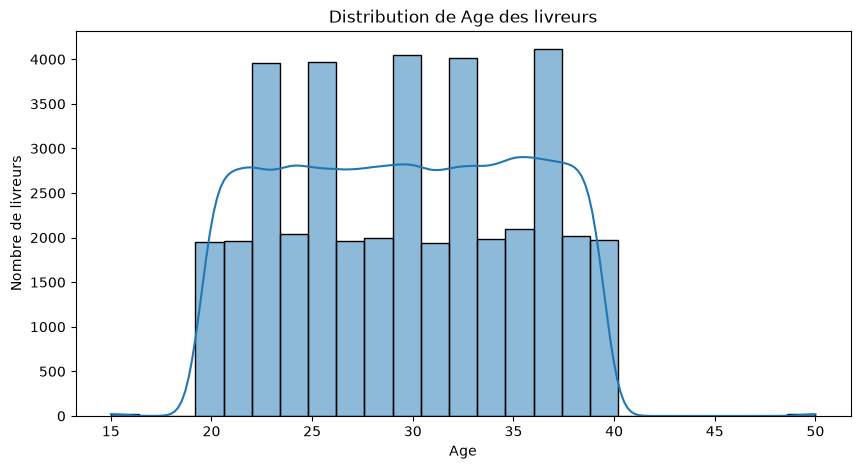

In [46]:
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Delivery_person_Age"],
    bins=25,
    kde=True
)

plt.title("Distribution de Age des livreurs")
plt.xlabel("Age")
plt.ylabel("Nombre de livreurs")
plt.show()

###  Traitement des valeurs manquantes de l'âge

Après l'analyse de la distribution des âges, les valeurs `15` et `50` ont été considérées comme des valeurs inhabituelles dans notre dataset.

Elles ont été remplacées par `NaN` afin de les traiter comme des valeurs manquantes.

Ensuite, les valeurs manquantes ont été remplacées par la **médiane** de l'âge.

La médiane obtenue est de **30 ans**.

Cette méthode permet de conserver les lignes du dataset tout en évitant d'utiliser des valeurs d'âge considérées comme suspectes.

Après le traitement :

- Les âges sont compris entre **20 et 39 ans**.
- Il n'y a plus de valeurs manquantes dans `Delivery_person_Age`.
- Les valeurs inhabituelles `15` et `50` ont été remplacées.
- Les valeurs manquantes ont été imputées avec la médiane `30`.

In [47]:
clean_df.loc[
    (clean_df["Delivery_person_Age"] < 20) |
    (clean_df["Delivery_person_Age"] > 39),
    "Delivery_person_Age"
] = np.nan


clean_df["Delivery_person_Age"].value_counts().sort_index()

clean_df["Delivery_person_Age"] = clean_df["Delivery_person_Age"].fillna(clean_df["Delivery_person_Age"].median())

clean_df["Delivery_person_Age"].value_counts().sort_index()



Delivery_person_Age
20.0    1955
21.0    1961
22.0    2021
23.0    1933
24.0    2035
25.0    1984
26.0    1980
27.0    1966
28.0    1997
29.0    2007
30.0    3561
31.0    1936
32.0    1999
33.0    2010
34.0    1986
35.0    2093
36.0    2070
37.0    2042
38.0    2018
39.0    1968
Name: count, dtype: int64

###  Traitement de `multiple_deliveries`

La variable `multiple_deliveries` représente le nombre de livraisons multiples effectuées dans le même trajet.

Cette variable peut avoir une influence sur le temps de livraison : plus le nombre de livraisons est élevé, plus le trajet peut prendre du temps.

Nous allons d'abord analyser ses valeurs afin d'identifier les valeurs manquantes ou inhabituelles avant de les traiter.

In [48]:
clean_df["multiple_deliveries"].value_counts(dropna=False).sort_index()

clean_df["multiple_deliveries"] = clean_df["multiple_deliveries"].fillna(clean_df["multiple_deliveries"].mode()[0])

clean_df["multiple_deliveries"].value_counts(dropna=False).sort_index()


multiple_deliveries
0.0    12826
1.0    26544
2.0     1829
3.0      323
Name: count, dtype: int64

###  Analyse de `Time_Orderd`

La variable `Time_Orderd` représente l'heure à laquelle la commande a été passée.

L'heure de commande peut avoir une influence sur le temps de livraison, notamment pendant les périodes de forte activité.

Nous allons analyser cette variable afin d'identifier les valeurs manquantes et de préparer l'heure pour la création de nouvelles variables utiles au modèle.

In [49]:
clean_df["Time_Orderd"].value_counts(dropna=False).head(20)

Time_Orderd
NaN         1325
21:55:00     421
17:55:00     419
21:15:00     413
19:50:00     412
21:20:00     411
18:35:00     410
19:55:00     408
20:00:00     407
22:20:00     406
22:45:00     404
17:35:00     401
21:40:00     400
17:40:00     398
21:35:00     397
18:10:00     396
20:40:00     395
23:30:00     395
00:00:00     395
22:35:00     394
Name: count, dtype: int64

###  Conversion de `Time_Orderd`

La variable `Time_Orderd` représente l'heure à laquelle la commande a été passée.

Les valeurs sont sous le format `HH:MM:SS`, par exemple `21:55:00`.

La colonne a été convertie en format datetime avec `pd.to_datetime()` afin de pouvoir manipuler facilement les heures.

La date `1900-01-01` ajoutée automatiquement par pandas est simplement une date par défaut, car notre variable contient uniquement l'heure. Elle n'a aucune signification pour notre projet.

Nous allons ensuite extraire uniquement l'heure dans une nouvelle variable `order_hour`.

In [50]:
clean_df["Time_Orderd"] = pd.to_datetime(clean_df["Time_Orderd"], format="%H:%M:%S", errors="coerce")

clean_df["Time_Orderd"].isna().sum()

clean_df["Time_Orderd"].value_counts(dropna=False).head(20)

Time_Orderd
NaT                    1325
1900-01-01 21:55:00     421
1900-01-01 17:55:00     419
1900-01-01 21:15:00     413
1900-01-01 19:50:00     412
1900-01-01 21:20:00     411
1900-01-01 18:35:00     410
1900-01-01 19:55:00     408
1900-01-01 20:00:00     407
1900-01-01 22:20:00     406
1900-01-01 22:45:00     404
1900-01-01 17:35:00     401
1900-01-01 21:40:00     400
1900-01-01 17:40:00     398
1900-01-01 21:35:00     397
1900-01-01 18:10:00     396
1900-01-01 20:40:00     395
1900-01-01 23:30:00     395
1900-01-01 00:00:00     395
1900-01-01 22:35:00     394
Name: count, dtype: int64

###  Extraction de l'heure de commande

À partir de `Time_Orderd`, nous avons créé une nouvelle variable `order_hour` qui contient uniquement l'heure de la commande.

Cette variable est plus pratique pour l'analyse et la modélisation, car elle permet d'étudier l'influence de l'heure de commande sur le temps de livraison.

Les valeurs vont de `0` à `23`. Les valeurs manquantes correspondent aux commandes pour lesquelles `Time_Orderd` était manquant.

On remarque également que les commandes sont particulièrement nombreuses entre **17h et 23h**, ce qui correspond aux heures de forte activité.

In [51]:
clean_df["order_hour"] = clean_df["Time_Orderd"].dt.hour

clean_df["order_hour"].value_counts(dropna=False).sort_index()


order_hour
0.0      395
8.0     1673
9.0     1779
10.0    1820
11.0    1796
12.0     823
13.0     716
14.0     721
15.0     797
16.0     646
17.0    3934
18.0    4118
19.0    4215
20.0    4181
21.0    4301
22.0    4176
23.0    4106
NaN     1325
Name: count, dtype: int64

In [52]:
clean_df["order_hour"].isna().sum()
clean_df["order_hour"] = clean_df["order_hour"].fillna(clean_df["order_hour"].median())
clean_df["order_hour"].isna().sum()
clean_df["order_hour"].value_counts(dropna=False).sort_index()

order_hour
0.0      395
8.0     1673
9.0     1779
10.0    1820
11.0    1796
12.0     823
13.0     716
14.0     721
15.0     797
16.0     646
17.0    3934
18.0    4118
19.0    5540
20.0    4181
21.0    4301
22.0    4176
23.0    4106
Name: count, dtype: int64

###  Analyse de `Time_Order_picked`

`Time_Order_picked` représente l'heure à laquelle le livreur récupère la commande.

Cette variable peut influencer le temps total de livraison. Nous allons vérifier ses valeurs et ses éventuelles valeurs manquantes.

In [53]:
clean_df["Time_Order_picked"].value_counts(dropna=False).head(20)
clean_df["Time_Order_picked"].isna().sum()

np.int64(0)

Convert to Date

In [54]:
clean_df["Time_Order_picked"] = pd.to_datetime(
    clean_df["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

clean_df["Time_Order_picked"].head(20)

0    1900-01-01 11:45:00
1    1900-01-01 19:50:00
2    1900-01-01 08:45:00
3    1900-01-01 18:10:00
4    1900-01-01 13:45:00
5    1900-01-01 21:30:00
6    1900-01-01 19:30:00
7    1900-01-01 17:30:00
8    1900-01-01 21:05:00
9    1900-01-01 22:10:00
10   1900-01-01 15:05:00
11   1900-01-01 17:40:00
12   1900-01-01 09:30:00
13   1900-01-01 20:05:00
14   1900-01-01 20:35:00
15   1900-01-01 15:10:00
16   1900-01-01 20:40:00
17   1900-01-01 20:50:00
18   1900-01-01 21:30:00
19   1900-01-01 20:25:00
Name: Time_Order_picked, dtype: datetime64[us]

In [55]:
clean_df["pickup_hour"] = clean_df["Time_Order_picked"].dt.hour
clean_df["pickup_hour"].value_counts().sort_index()

pickup_hour
0     1196
8     1370
9     1854
10    1917
11    1815
12    1061
13     728
14     743
15     824
16     706
17    3368
18    4350
19    4241
20    4365
21    4412
22    4343
23    4229
Name: count, dtype: int64

###  Nettoyage de `Weatherconditions`

Nous supprimons le préfixe `conditions` afin de garder uniquement le type de météo.

In [56]:
clean_df["Weatherconditions"] =(
    clean_df["Weatherconditions"].str.replace("conditions ","",regex=False)
)

clean_df["Weatherconditions"].head(10)

0         Sunny
1        Stormy
2    Sandstorms
3         Sunny
4        Cloudy
5        Cloudy
6           Fog
7        Cloudy
8        Stormy
9           Fog
Name: Weatherconditions, dtype: str

In [57]:
clean_df["Weatherconditions"].value_counts()

Weatherconditions
Fog           6962
Stormy        6932
Cloudy        6881
Sandstorms    6853
Windy         6792
Sunny         6682
NaN            420
Name: count, dtype: int64

In [58]:


clean_df["Weatherconditions"] = clean_df["Weatherconditions"].replace(
    "NaN", np.nan
)

clean_df["Weatherconditions"] = clean_df["Weatherconditions"].fillna(
    clean_df["Weatherconditions"].mode()[0]
)

clean_df["Weatherconditions"].isna().sum()

np.int64(0)

In [59]:
clean_df["Weatherconditions"].value_counts()

Weatherconditions
Fog           7382
Stormy        6932
Cloudy        6881
Sandstorms    6853
Windy         6792
Sunny         6682
Name: count, dtype: int64

###  Conversion de `Order_Date`

La colonne `Order_Date` est convertie en format `datetime` pour faciliter son analyse.

In [60]:
clean_df["Order_Date"] = pd.to_datetime(
    clean_df["Order_Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

clean_df["Order_Date"].isna().sum()

np.int64(0)

In [61]:
clean_df["Order_Date"].value_counts().sort_index()

Order_Date
2022-02-11     769
2022-02-12     694
2022-02-13     755
2022-02-14     687
2022-02-15     753
2022-02-16     708
2022-02-17     755
2022-02-18     698
2022-03-01    1061
2022-03-02     941
2022-03-03    1068
2022-03-04     919
2022-03-05    1068
2022-03-06     916
2022-03-07    1065
2022-03-08     896
2022-03-09    1085
2022-03-10     926
2022-03-11    1070
2022-03-12     905
2022-03-13    1091
2022-03-14     908
2022-03-15    1109
2022-03-16     922
2022-03-17    1053
2022-03-18     902
2022-03-19    1068
2022-03-20     927
2022-03-21    1069
2022-03-23     896
2022-03-24    1086
2022-03-25     911
2022-03-26    1090
2022-03-27     897
2022-03-28    1058
2022-03-29     908
2022-03-30    1061
2022-03-31     897
2022-04-01    1056
2022-04-02     925
2022-04-03    1099
2022-04-04     879
2022-04-05    1085
2022-04-06     886
Name: count, dtype: int64

In [62]:
clean_df.columns.tolist()


['Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Time_taken(min)',
 'distance',
 'order_hour',
 'pickup_hour']

In [63]:
clean_df["Road_traffic_density"].head(20)
clean_df["Road_traffic_density"].value_counts(dropna=False)

Road_traffic_density
Low        14095
Jam        12950
Medium     10023
High        4046
Unknown      408
Name: count, dtype: int64

In [64]:
clean_df["Road_traffic_density"] = clean_df["Road_traffic_density"].replace(
    np.nan, 
    clean_df["Road_traffic_density"].mode()[0]
)

clean_df["Road_traffic_density"].isna().sum()
clean_df["Road_traffic_density"].value_counts()

Road_traffic_density
Low        14095
Jam        12950
Medium     10023
High        4046
Unknown      408
Name: count, dtype: int64

###  Vérification de `Type_of_vehicle`

Nous vérifions les catégories de véhicules et les éventuelles valeurs manquantes.

In [65]:
clean_df["Type_of_vehicle"].value_counts(dropna=False)

Type_of_vehicle
motorcycle           24197
scooter              13878
electric_scooter      3404
bicycle                 43
Name: count, dtype: int64

###  Vérification de `multiple_deliveries`

Nous vérifions les valeurs et les éventuelles valeurs manquantes.

In [66]:
clean_df["multiple_deliveries"].value_counts(dropna=False)

multiple_deliveries
1.0    26544
0.0    12826
2.0     1829
3.0      323
Name: count, dtype: int64

###  Vérification de `Time_taken(min)`

Nous vérifions les valeurs du temps de livraison avant la modélisation.

In [67]:
clean_df["Time_taken(min)"].describe()

count    41522.000000
mean        26.315447
std          9.380634
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

###  Vérification de `Delivery_person_Ratings`

Nous vérifions la distribution des notes et les éventuelles valeurs manquantes.

In [68]:
clean_df["Delivery_person_Ratings"].describe()

count    41522.000000
mean         4.634261
std          0.321795
min          1.000000
25%          4.500000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

###  Vérification de `Delivery_person_Age`

Nous vérifions la distribution des âges après le nettoyage.

In [69]:
clean_df["Delivery_person_Age"].describe()

count    41522.000000
mean        29.568807
std          5.655790
min         20.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         39.000000
Name: Delivery_person_Age, dtype: float64

###  Vérification de `distance`

Nous vérifions la distribution des distances après le nettoyage des valeurs extrêmes.

In [70]:
clean_df["distance"].describe()

count    41522.000000
mean         9.704133
std          5.593935
min          1.463837
25%          4.648474
50%          9.177295
75%         13.659637
max         20.942906
Name: distance, dtype: float64

###  Vérification finale des valeurs manquantes

Nous vérifions qu'il ne reste aucune valeur manquante dans le dataset.

In [71]:
clean_df.isna().sum()

Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1325
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Type_of_vehicle                   0
multiple_deliveries               0
Time_taken(min)                   0
distance                          0
order_hour                        0
pickup_hour                       0
dtype: int64

In [72]:
clean_df["order_hour"] = clean_df["order_hour"].fillna(
    clean_df["order_hour"].median()
)

In [73]:
clean_df = clean_df.drop(
    columns=["Time_Orderd", "Time_Order_picked"]
)

In [74]:
clean_df.isna().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
Time_taken(min)                0
distance                       0
order_hour                     0
pickup_hour                    0
dtype: int64

##  Résumé du nettoyage des données

Dans cette étape, nous avons préparé et nettoyé le dataset afin de le rendre exploitable pour la modélisation.

Les principales opérations réalisées sont :

- Remplacement des valeurs manquantes `NaN` et des valeurs invalides.
- Conversion des variables dans les types appropriés (`numeric`, `datetime`, etc.).
- Traitement des valeurs aberrantes, notamment l'âge et les coordonnées géographiques.
- Imputation de certaines valeurs manquantes avec la **médiane** ou le **mode**.
- Nettoyage et normalisation des variables catégorielles comme `Weatherconditions` et `Road_traffic_density`.
- Suppression des colonnes peu utiles pour notre objectif (`ID`, `Delivery_person_ID`, `City`, `Festival`, etc.).
- Création de nouvelles variables utiles à la modélisation : `order_hour`, `pickup_hour` et `distance`.
- Calcul de la distance entre le restaurant et le lieu de livraison avec `geopy`.
- Suppression des distances considérées comme anormalement élevées.
- Vérification finale des valeurs manquantes.

Après ces traitements, le dataset ne contient plus de valeurs manquantes et est prêt pour l'analyse exploratoire et la préparation du modèle.

In [75]:
clean_df.value_counts()

Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude  Order_Date  Weatherconditions  Road_traffic_density  Type_of_vehicle  multiple_deliveries  Time_taken(min)  distance   order_hour  pickup_hour
37.0                 4.9                      22.745049            75.892471             22.765049                   75.912471                    2022-03-19  Sunny              High                  motorcycle       0.0                  24               3.020737   11.0        11             1
34.0                 4.5                      12.913041            77.683237             13.043041                   77.813237                    2022-03-25  Stormy             Jam                   scooter          1.0                  33               20.143737  19.0        19             1
23.0                 4.4                      12.914264            77.678400             12.924264                   77.688

In [76]:
clean_df.to_csv("../data/cleaned_data.csv", index=False)